# Analisis Perubahan Garis Pantai dengan Data Landsat (DEA Coastlines)

Notebook ini merupakan implementasi analisis perubahan garis pantai menggunakan citra satelit Landsat multi-temporal. Algoritma diadaptasi dari **DEA Coastlines** (*Digital Earth Australia Coastlines*) yang dikembangkan oleh Geoscience Australia.

**Referensi:**
- Repositori asli: [dea-coastlines](https://github.com/geoscienceAustralia/dea-coastlines)
- Versi generik terbaru: [coastlines (auspatious)](https://github.com/auspatious/coastlines)

---

## Prinsip Kerja Algoritma

Algoritma ini bekerja dengan dua dataset utama:
1. **Data Optik (Landsat)** — citra multispektral Landsat dari berbagai generasi (LS5, LS7, LS8, LS9) yang merekam kondisi permukaan bumi sejak 1984.
2. **Model Pasang Surut** — digunakan untuk menganotasi setiap scene dengan tinggi pasang surut, kemudian memfilter hanya scene yang berada di tengah rentang pasang surut (*mean sea level*), sehingga menghasilkan garis pantai rata-rata.

---

## Alur Kerja (Workflow)

```
1. Import Library & Konfigurasi
        ↓
2. Tentukan Lokasi & Rentang Waktu
        ↓
3. Pencarian Data Landsat (via STAC)
        ↓
4. Load & Cloud Masking
        ↓
5. Tide Masking (Filter Pasang Surut)
        ↓
6. Hitung Water Index (NDWI/MNDWI)
        ↓
7. Ekstraksi Kontur Garis Pantai
        ↓
8. Analisis Perubahan & Visualisasi
        ↓
9. Ekspor Hasil
```

## 1. Import Library dan Konfigurasi Awal

Pada tahap ini, kita mengimpor semua library Python yang dibutuhkan dalam proses analisis. Library dibagi berdasarkan fungsinya:

- **Manipulasi Data**: `pandas`, `numpy`, `xarray`
- **Data Geospasial**: `geopandas`, `shapely`, `odc.geo`
- **Visualisasi**: `matplotlib`, `seaborn`, `leafmap`
- **Earth Observation**: `datacube`, `eo_tides`, `odc.stac`
- **Coastline Tools**: `configs`, `coastlines`, `dea_tools`
- **Komputasi Paralel**: `dask.distributed`

In [1]:
import os
import warnings
import pandas as pd
import geopandas as gpd
import numpy as np
import xarray as xr
import leafmap.foliumap as leafmap
import matplotlib.pyplot as plt
import seaborn as sns

from configs import load_mask, tide_mask, water_index
from coastlines.utils import extract_contours
from coastlines.vector import annual_movements, calculate_regressions
from dea_tools.spatial import points_on_line
from dask.distributed import Client
from datacube import Datacube
from datacube.utils.masking import create_mask_value, valid_data_mask
from eo_tides import tide_stats
from eo_tides.utils import list_models
from ipyleaflet import basemaps
from odc.geo.geom import point
from odc.stac import configure_s3_access
from piksel.utils import patch_usgs_landsat
from pystac_client import Client as STACClient
from shapely.geometry import box

# Suppress minor warnings agar output lebih bersih
warnings.filterwarnings('ignore')

print("✅ Semua library berhasil diimport.")

✅ Semua library berhasil diimport.


## 2. Konfigurasi Lingkungan (Environment Setup)

Pada tahap ini kita melakukan:
- Memuat dan menampilkan daftar **model pasang surut** yang tersedia di direktori lokal.
- Mengkonfigurasi **akses AWS S3** untuk mengunduh data Landsat secara langsung dari cloud.
- Menginisialisasi koneksi ke **Open Data Cube (ODC)** sebagai backend penyimpanan data.
- Membuat **Dask Client** untuk komputasi paralel dan terdistribusi, yang mempercepat pemrosesan data berukuran besar.

> **Catatan:** Model pasang surut `FES2022` dipilih karena memiliki akurasi tinggi untuk wilayah Asia Tenggara.

In [2]:
# Direktori penyimpanan model pasang surut
tide_data_location = "/home/jovyan/data/coastlines/tide_models"

# Tampilkan model yang tersedia
models = list_models(directory=tide_data_location, show_supported=False)
print(f"Model pasang surut tersedia: {models}")

────────────────────────────────────────────────────────────────────────────────
 󠀠🌊  | Model                | Expected path                                                               
────────────────────────────────────────────────────────────────────────────────
 ✅  │ EOT20                │ /home/jovyan/data/coastlines/tide_models/EOT20/ocean_tides                  
 ✅  │ EOT20_load           │ /home/jovyan/data/coastlines/tide_models/EOT20/load_tides                   
 ✅  │ FES2014              │ /home/jovyan/data/coastlines/tide_models/fes2014/ocean_tide                 
 ✅  │ FES2014_extrapolated │ /home/jovyan/data/coastlines/tide_models/fes2014/ocean_tide_extrapolated    
 ✅  │ FES2014_load         │ /home/jovyan/data/coastlines/tide_models/fes2014/load_tide                  
 ✅  │ FES2022              │ /home/jovyan/data/coastlines/tide_models/fes2022b/ocean_tide_20241025       
 ✅  │ FES2022_extrapolated │ /home/jovyan/data/coastlines/tide_models/fes2022b/ocean_tide_extra

In [3]:
# Model pasang surut yang digunakan
model = "INATIDES"

# Konfigurasi akses AWS S3 (region us-west-2 adalah lokasi data Landsat Collection 2)
os.environ["AWS_DEFAULT_REGION"] = "us-west-2"

# Hapus variabel AWS_NO_SIGN_REQUEST jika ada, agar request signing aktif
if "AWS_NO_SIGN_REQUEST" in os.environ:
    del os.environ["AWS_NO_SIGN_REQUEST"]

# Aktifkan akses S3 dengan requester-pays (biaya ditanggung pengguna)
configure_s3_access(requester_pays=True)

# Koneksi ke Open Data Cube
dc = Datacube(app="coastlines")

# Inisialisasi Dask Client untuk komputasi paralel
# n_workers=4: 4 proses paralel | threads_per_worker=8: 8 thread per proses
dask_client = Client(n_workers=4, threads_per_worker=8)
print(f"✅ Dask Client aktif. Dashboard: {dask_client.dashboard_link}")
dask_client

✅ Dask Client aktif. Dashboard: /user/wppratamaa@gmail.com/proxy/8787/status


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /user/wppratamaa@gmail.com/proxy/8787/status,
Dashboard: /user/wppratamaa@gmail.com/proxy/8787/status,Workers: 4
Total threads: 32,Total memory: 124.44 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:34055,Workers: 0
Dashboard: /user/wppratamaa@gmail.com/proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:35331,Total threads: 8
Dashboard: /user/wppratamaa@gmail.com/proxy/43681/status,Memory: 31.11 GiB
Nanny: tcp://127.0.0.1:36931,


## 3. Definisi Area Kajian dan Rentang Waktu

Pada tahap ini kita mendefinisikan:
- **Rentang waktu** analisis (tahun awal hingga akhir).
- **Koordinat bounding box** area kajian dalam sistem koordinat geografis WGS84 (EPSG:4326).
- **Threshold tutupan awan** maksimum yang diizinkan per scene.

Area kajian divisualisasikan menggunakan peta interaktif dengan basemap citra satelit ESRI World Imagery.

> **⚠️ Penting:** Perhatikan urutan koordinat `lon_range` — nilai pertama harus lebih kecil (barat) dan nilai kedua lebih besar (timur). Nilai yang terbalik akan menyebabkan bounding box tidak valid.

In [4]:
# --- Parameter Waktu ---
start_date = "2015"
end_date   = "2026"

# --- Parameter Kualitas ---
max_cloud_cover = 30  # Persen tutupan awan maksimum yang diizinkan

# --- Koordinat Area Kajian ---
# PERBAIKAN: lon_range diperbaiki urutan nilainya (min, max) agar valid sebagai bounding box
# Nilai asli: (97.252771, 97.204416) → terbalik (barat > timur)
lat_range = (1.437722, 1.444254)   # (selatan, utara)
lon_range = (97.233876, 97.223446) # (barat, timur)  ← DIPERBAIKI

# Buat polygon bounding box dari koordinat
area = box(lon_range[0], lat_range[0], lon_range[1], lat_range[1])
gdf  = gpd.GeoDataFrame(geometry=[area], crs="EPSG:4326")

# --- Visualisasi Interaktif ---
m = leafmap.Map()
m.add_basemap("HYBRID")
m.add_gdf(gdf, layer_name="Area of Interest")
m.zoom_to_gdf(gdf)
print(f"📍 Area Kajian: Lat {lat_range}, Lon {lon_range}")
print(f"📅 Rentang Waktu: {start_date} – {end_date}")
m

📍 Area Kajian: Lat (1.437722, 1.444254), Lon (97.233876, 97.223446)
📅 Rentang Waktu: 2015 – 2026


## 4. Pencarian Data Landsat via STAC Catalog

Kita menggunakan **STAC (SpatioTemporal Asset Catalog)** dari AWS Earth Search untuk menemukan semua scene Landsat Collection 2 Level-2 yang tersedia di area kajian. Pendekatan STAC dipilih karena:
- Lebih fleksibel dibanding pencarian langsung via ODC
- Mendukung filter berdasarkan bbox, tanggal, dan persentase awan
- Menghasilkan metadata lengkap yang bisa divisualisasikan

Hasil pencarian ditampilkan sebagai grafik distribusi jumlah scene per tahun untuk memvalidasi ketersediaan data.

In [5]:
# Koneksi ke STAC Catalog AWS Earth Search
catalog = STACClient.open("https://earth-search.aws.element84.com/v1")

# Pencarian scene Landsat Collection 2 Level-2
search = catalog.search(
    collections=["landsat-c2-l2"],
    bbox=[lon_range[0], lat_range[0], lon_range[1], lat_range[1]],
    datetime=f"{start_date}-01-01/{end_date}-12-31",
    query={"eo:cloud_cover": {"lt": max_cloud_cover}},
)

items = list(search.get_items())
print(f"✅ Total scene Landsat ditemukan: {len(items)} scene")

✅ Total scene Landsat ditemukan: 237 scene


### 4.1 Visualisasi Distribusi Data per Tahun

Grafik berikut menunjukkan ketersediaan data Landsat per tahun di area kajian. Informasi ini penting untuk:
- Mengidentifikasi tahun dengan data yang terbatas (dapat mempengaruhi kualitas analisis)
- Mendeteksi gap temporal yang mungkin perlu ditangani
- Memahami kontribusi tiap sensor Landsat (LS5, LS7, LS8, LS9)

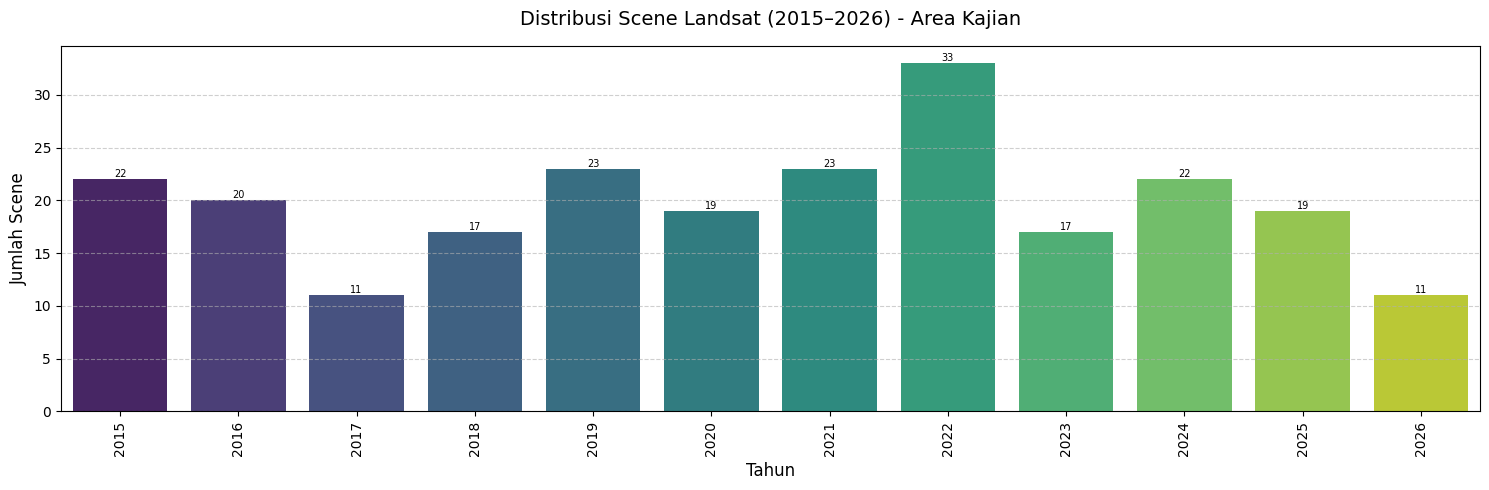


Ringkasan statistik:
             Tahun  Jumlah Citra
count    12.000000     12.000000
mean   2020.500000     19.750000
std       3.605551      5.848465
min    2015.000000     11.000000
25%    2017.750000     17.000000
50%    2020.500000     19.500000
75%    2023.250000     22.250000
max    2026.000000     33.000000


In [6]:
# Siapkan DataFrame distribusi tahunan
df = pd.DataFrame({"date": [item.datetime for item in items]})
df["year"] = df["date"].dt.year
count_per_year = df["year"].value_counts().sort_index().reset_index()
count_per_year.columns = ["Tahun", "Jumlah Citra"]

# Visualisasi
fig, ax = plt.subplots(figsize=(15, 5))
sns.barplot(data=count_per_year, x="Tahun", y="Jumlah Citra", palette="viridis", ax=ax)

ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
ax.set_title(f"Distribusi Scene Landsat ({start_date}–{end_date}) - Area Kajian", fontsize=14, pad=15)
ax.set_xlabel("Tahun", fontsize=12)
ax.set_ylabel("Jumlah Scene", fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.6)

# Tambahkan label jumlah di atas setiap bar
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{int(p.get_height())}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.show()

print(f"\nRingkasan statistik:")
print(count_per_year.describe())

## 5. Load Data Landsat via Open Data Cube

Setelah mengetahui ketersediaan data, kita memuat citra Landsat menggunakan **Open Data Cube (ODC)**. Data dimuat dengan konfigurasi berikut:

- **Produk**: LS5, LS7, LS8, LS9 (Collection 2, Level-2, Surface Reflectance)
- **Band**: Red, Green, Blue, NIR (Near-Infrared), SWIR1, dan QA Pixel
- **Resolusi**: 30 meter
- **CRS Output**: EPSG:6933 (Equal-Area projection, sesuai untuk analisis area)
- **Resampling**: Cubic untuk band spektral, Nearest untuk band QA
- **Dask Chunks**: Untuk lazy loading dan pemrosesan terdistribusi

> **Catatan:** `group_by="solar_day"` memastikan scene dari sensor berbeda pada hari yang sama digabungkan menjadi satu slice waktu.

In [7]:
# Definisi kategori piksel yang akan dimasking (awan & bayangan awan)
categories_to_mask_landsat = {
    "cloud": "high_confidence",
    "cloud_shadow": "high_confidence",
}

# Pencarian dataset melalui ODC (diperlukan untuk membaca flag QA)
landsat_datasets = dc.find_datasets(
    product=["ls5_c2l2_sr", "ls7_c2l2_sr", "ls8_c2l2_sr", "ls9_c2l2_sr"],
    time=(start_date, end_date),
    longitude=lon_range,
    latitude=lat_range,
    cloud_cover=(0, max_cloud_cover)
)

print(f"✅ Ditemukan {len(landsat_datasets)} dataset Landsat di ODC")

# Load data sebagai xarray Dataset dengan Dask (lazy loading)
data = dc.load(
    datasets=landsat_datasets,
    longitude=lon_range,
    latitude=lat_range,
    resolution=30,
    output_crs="EPSG:6933",
    measurements=["red", "green", "blue", "nir08", "swir16", "qa_pixel"],
    group_by="solar_day",
    dask_chunks={"time": 1, "x": 1024, "y": 1024},
    resampling={
        "*": "cubic",           # Cubic untuk band spektral
        "qa_pixel": "nearest",  # Nearest untuk band klasifikasi/QA
    },
    patch_url=patch_usgs_landsat,
    driver="rio",
)

print(f"✅ Data berhasil dimuat: {data.dims}")
data

✅ Ditemukan 242 dataset Landsat di ODC
✅ Data berhasil dimuat: FrozenMappingWarningOnValuesAccess({'y': 28, 'x': 35, 'time': 237})


<xarray.Dataset> Size: 3MB
Dimensions:      (y: 28, x: 35, time: 237)
Coordinates:
  * y            (y) float64 224B 1.842e+05 1.842e+05 ... 1.834e+05 1.834e+05
  * x            (x) float64 280B 9.381e+06 9.381e+06 ... 9.382e+06 9.382e+06
  * time         (time) datetime64[ns] 2kB 2015-01-03T03:46:03.800128 ... 202...
    spatial_ref  int32 4B 6933
Data variables:
    red          (time, y, x) uint16 465kB dask.array<chunksize=(1, 28, 35), meta=np.ndarray>
    green        (time, y, x) uint16 465kB dask.array<chunksize=(1, 28, 35), meta=np.ndarray>
    blue         (time, y, x) uint16 465kB dask.array<chunksize=(1, 28, 35), meta=np.ndarray>
    nir08        (time, y, x) uint16 465kB dask.array<chunksize=(1, 28, 35), meta=np.ndarray>
    swir16       (time, y, x) uint16 465kB dask.array<chunksize=(1, 28, 35), meta=np.ndarray>
    qa_pixel     (time, y, x) uint16 465kB dask.array<chunksize=(1, 28, 35), meta=np.ndarray>
Attributes:
    crs:           EPSG:6933
    grid_mapping:  spatial_ref

## 6. Cloud Masking (Masking Awan)

Cloud masking adalah proses menghilangkan piksel yang terkena awan atau bayangan awan dari dataset. Proses ini penting karena piksel yang tertutup awan akan menghasilkan nilai reflektansi yang tidak merepresentasikan kondisi permukaan tanah sesungguhnya.

**Alur cloud masking:**
1. Baca flag QA dari band `qa_pixel` (format Landsat Collection 2)
2. Buat mask untuk piksel awan dan bayangan dengan confidence tinggi
3. Gabungkan dengan mask valid data (piksel di luar batas scene)
4. Terapkan mask ke semua band — piksel bermasalah diubah menjadi `NaN`
5. Hapus band `qa_pixel` yang tidak lagi dibutuhkan
6. **Konversi ke nilai reflektansi permukaan**: `DN × 0.0000275 - 0.2` (faktor skala resmi Landsat C2L2)

> Nilai reflektansi yang valid berada antara 0–1 (0% hingga 100% reflektansi).

In [8]:
# Buat nilai bitmask untuk cloud dan cloud_shadow dari definisi flag QA
mask_value, _ = create_mask_value(
    landsat_datasets[0].product.measurements["qa_pixel"].flags_definition,
    **categories_to_mask_landsat,
)

# Identifikasi piksel yang terkena awan
cloud_mask = (data.qa_pixel & mask_value) != 0

# Identifikasi piksel yang memiliki data valid (dalam batas scene)
valid_data = valid_data_mask(data)

# Gabungan mask: piksel dibuang jika terkena awan ATAU tidak valid
mask = cloud_mask | ~valid_data

# Terapkan mask: piksel bermasalah menjadi NaN, hapus band QA
masked = data.where(~mask).drop_vars("qa_pixel")

# Konversi Digital Number (DN) ke Surface Reflectance (0–1)
# Rumus resmi Landsat Collection 2: SR = DN × 0.0000275 - 0.2
masked = (masked * 0.0000275 - 0.2).clip(0, 1)

print(f"✅ Cloud masking selesai. Dimensi data: {masked.dims}")
print(f"   Band tersedia: {list(masked.data_vars)}")
masked

✅ Cloud masking selesai. Dimensi data: FrozenMappingWarningOnValuesAccess({'time': 237, 'y': 28, 'x': 35})
   Band tersedia: ['red', 'green', 'blue', 'nir08', 'swir16']


<xarray.Dataset> Size: 5MB
Dimensions:      (time: 237, y: 28, x: 35)
Coordinates:
  * time         (time) datetime64[ns] 2kB 2015-01-03T03:46:03.800128 ... 202...
  * y            (y) float64 224B 1.842e+05 1.842e+05 ... 1.834e+05 1.834e+05
  * x            (x) float64 280B 9.381e+06 9.381e+06 ... 9.382e+06 9.382e+06
    spatial_ref  int32 4B 6933
Data variables:
    red          (time, y, x) float32 929kB dask.array<chunksize=(1, 28, 35), meta=np.ndarray>
    green        (time, y, x) float32 929kB dask.array<chunksize=(1, 28, 35), meta=np.ndarray>
    blue         (time, y, x) float32 929kB dask.array<chunksize=(1, 28, 35), meta=np.ndarray>
    nir08        (time, y, x) float32 929kB dask.array<chunksize=(1, 28, 35), meta=np.ndarray>
    swir16       (time, y, x) float32 929kB dask.array<chunksize=(1, 28, 35), meta=np.ndarray>
Attributes:
    crs:           EPSG:6933
    grid_mapping:  spatial_ref

## 7. Tide Masking (Filter Pasang Surut)

Tahap ini adalah inti dari algoritma DEA Coastlines. Setiap scene Landsat dianotasi dengan tinggi pasang surut menggunakan model **FES2022**, kemudian hanya scene yang diambil saat pasang surut berada di **tengah 50% rentang pasang surut** yang dipertahankan.

**Mengapa perlu tide masking?**
- Garis pantai sangat dipengaruhi oleh kondisi pasang surut
- Scene yang diambil saat air laut tinggi (high tide) akan menunjukkan garis pantai lebih "ke darat"
- Scene saat air surut (low tide) akan menunjukkan area yang tidak biasanya tergenang
- Dengan memfilter ke tengah rentang pasang surut, kita mendapatkan estimasi **Mean Sea Level (MSL)** yang konsisten

Fungsi `tide_mask()` dari `configs` melakukan seluruh proses ini secara otomatis.

In [9]:
# Terapkan tide masking: filter scene berdasarkan tinggi pasang surut
# Fungsi ini: (1) prediksi tinggi pasang tiap scene, (2) hitung persentil,
# (3) filter hanya scene dalam 50% tengah distribusi pasang surut
data_tide_masked = tide_mask(masked, tide_data_location, model)

print(f"✅ Tide masking selesai.")
print(f"   Scene sebelum tide masking : {len(masked.time)}")
print(f"   Scene setelah tide masking : {len(data_tide_masked.time)}")

Creating reduced resolution 5000 x 5000 metre tide modelling array
Modelling tides with INATIDES
Reprojecting tides into original resolution


/home/jovyan/indonesia-coastlines/.venv/lib/python3.12/site-packages/rasterio/warp.py:385: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(


✅ Tide masking selesai.
   Scene sebelum tide masking : 237
   Scene setelah tide masking : 153


### 7.1 Statistik Pasang Surut

Visualisasi distribusi prediksi pasang surut untuk seluruh dataset. Ini membantu memvalidasi apakah model pasang surut bekerja dengan benar dan memberikan gambaran karakteristik pasang surut di area kajian.

Using tide modelling location: 97.23, 1.44
Modelling tides with EOT20
Using tide modelling location: 97.23, 1.44
Modelling tides with EOT20


🌊 Modelled astronomical tide range: 1.00 m (-0.44 to 0.56 m).
🛰️ Observed tide range: 0.36 m (-0.18 to 0.18 m).

🔴 36% of the modelled astronomical tide range was observed at this location.
🔴 The highest 38% (0.38 m) of the tide range was never observed.
🔴 The lowest 26% (0.26 m) of the tide range was never observed.

🌊 Mean modelled astronomical tide height: 0.00 m.
🛰️ Mean observed tide height: -0.01 m.
⬇️ The mean observed tide height was -0.01 m lower than the mean modelled astronomical tide height.
📊 Statistik Pasang Surut:
mot            -0.006000
mat             0.000000
hot             0.179000
hat             0.562000
lot            -0.184000
lat            -0.442000
otr             0.363000
tr              1.004000
spread          0.362000
offset_low      0.257000
offset_high     0.381000
x              97.228996
y               1.44100

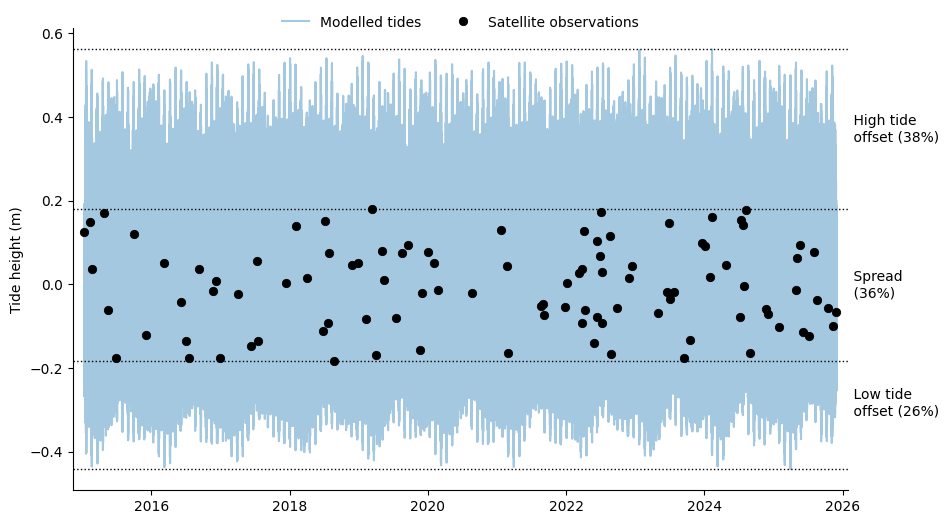

In [14]:
# Hitung dan tampilkan statistik pasang surut
stats = tide_stats(
    data=data_tide_masked,
    model=model,
    directory=tide_data_location,
)

print("📊 Statistik Pasang Surut:")
print(stats)

## 8. Perhitungan Water Index dan Agregasi Tahunan

Setelah filtering, kita menghitung **water index** untuk membedakan piksel air dan daratan. Ada dua opsi indeks:

| Indeks | Rumus | Keterangan |
|--------|-------|------------|
| `mndwi_nir` | (Green - NIR) / (Green + NIR) | NDWI standar, threshold ~0.65 |
| `combined` | rata-rata NDWI + MNDWI | Lebih robust untuk wilayah pesisir, threshold 0.0 |

Fungsi `water_index()` juga melakukan **agregasi median tahunan**, yaitu mengelompokkan seluruh scene per tahun dan menghitung nilai median tiap piksel — menghasilkan satu layer komposit per tahun yang representatif dan bebas noise.

> Nilai indeks **positif** → air/laut | Nilai **negatif** → darat/vegetasi

In [10]:
# Pilih tipe water index
# 'combined'   → threshold z_value = 0.0 
# 'mndwi_nir'  → threshold z_value = 0.65
# 'scowi'   → threshold z_value = 0.0 
wi = "mndwi_nir"

# Hitung water index dan grupkan per tahun (median)
grouped_by_year = water_index(wi, data_tide_masked)

print(f"✅ Water index '{wi}' berhasil dihitung.")
print(f"   Jumlah tahun: {len(grouped_by_year.year)}")
grouped_by_year

✅ Water index 'mndwi_nir' berhasil dihitung.
   Jumlah tahun: 12


<xarray.Dataset> Size: 48kB
Dimensions:      (y: 28, x: 35, year: 12)
Coordinates:
  * y            (y) float64 224B 1.842e+05 1.842e+05 ... 1.834e+05 1.834e+05
  * x            (x) float64 280B 9.381e+06 9.381e+06 ... 9.382e+06 9.382e+06
  * year         (year) int64 96B 2015 2016 2017 2018 ... 2023 2024 2025 2026
    spatial_ref  int32 4B 6933
    tide_model   <U8 32B 'INATIDES'
Data variables:
    mndwi_nir    (year, y, x) float32 47kB dask.array<chunksize=(1, 28, 35), meta=np.ndarray>

### 8.1 Komputasi ke Memory

Hingga tahap ini, semua operasi masih bersifat **lazy** (belum benar-benar dihitung, hanya didefinisikan sebagai graph komputasi). Perintah `.compute()` memicu Dask untuk menjalankan seluruh pipeline dan memuat hasilnya ke RAM.

> Proses ini bisa memakan waktu beberapa menit tergantung ukuran data dan jumlah worker Dask.

In [11]:
print("⏳ Memulai komputasi... Harap tunggu.")
grouped_by_year = grouped_by_year.compute()
print("✅ Komputasi selesai. Data tersimpan di memory.")

⏳ Memulai komputasi... Harap tunggu.
✅ Komputasi selesai. Data tersimpan di memory.


### 8.2 Visualisasi Water Index per Tahun

Tampilkan peta water index komposit tahunan. Warna merah menunjukkan daratan (nilai negatif) dan warna biru menunjukkan air laut (nilai positif). Perubahan batas antara kedua zona inilah yang menggambarkan perubahan garis pantai dari tahun ke tahun.

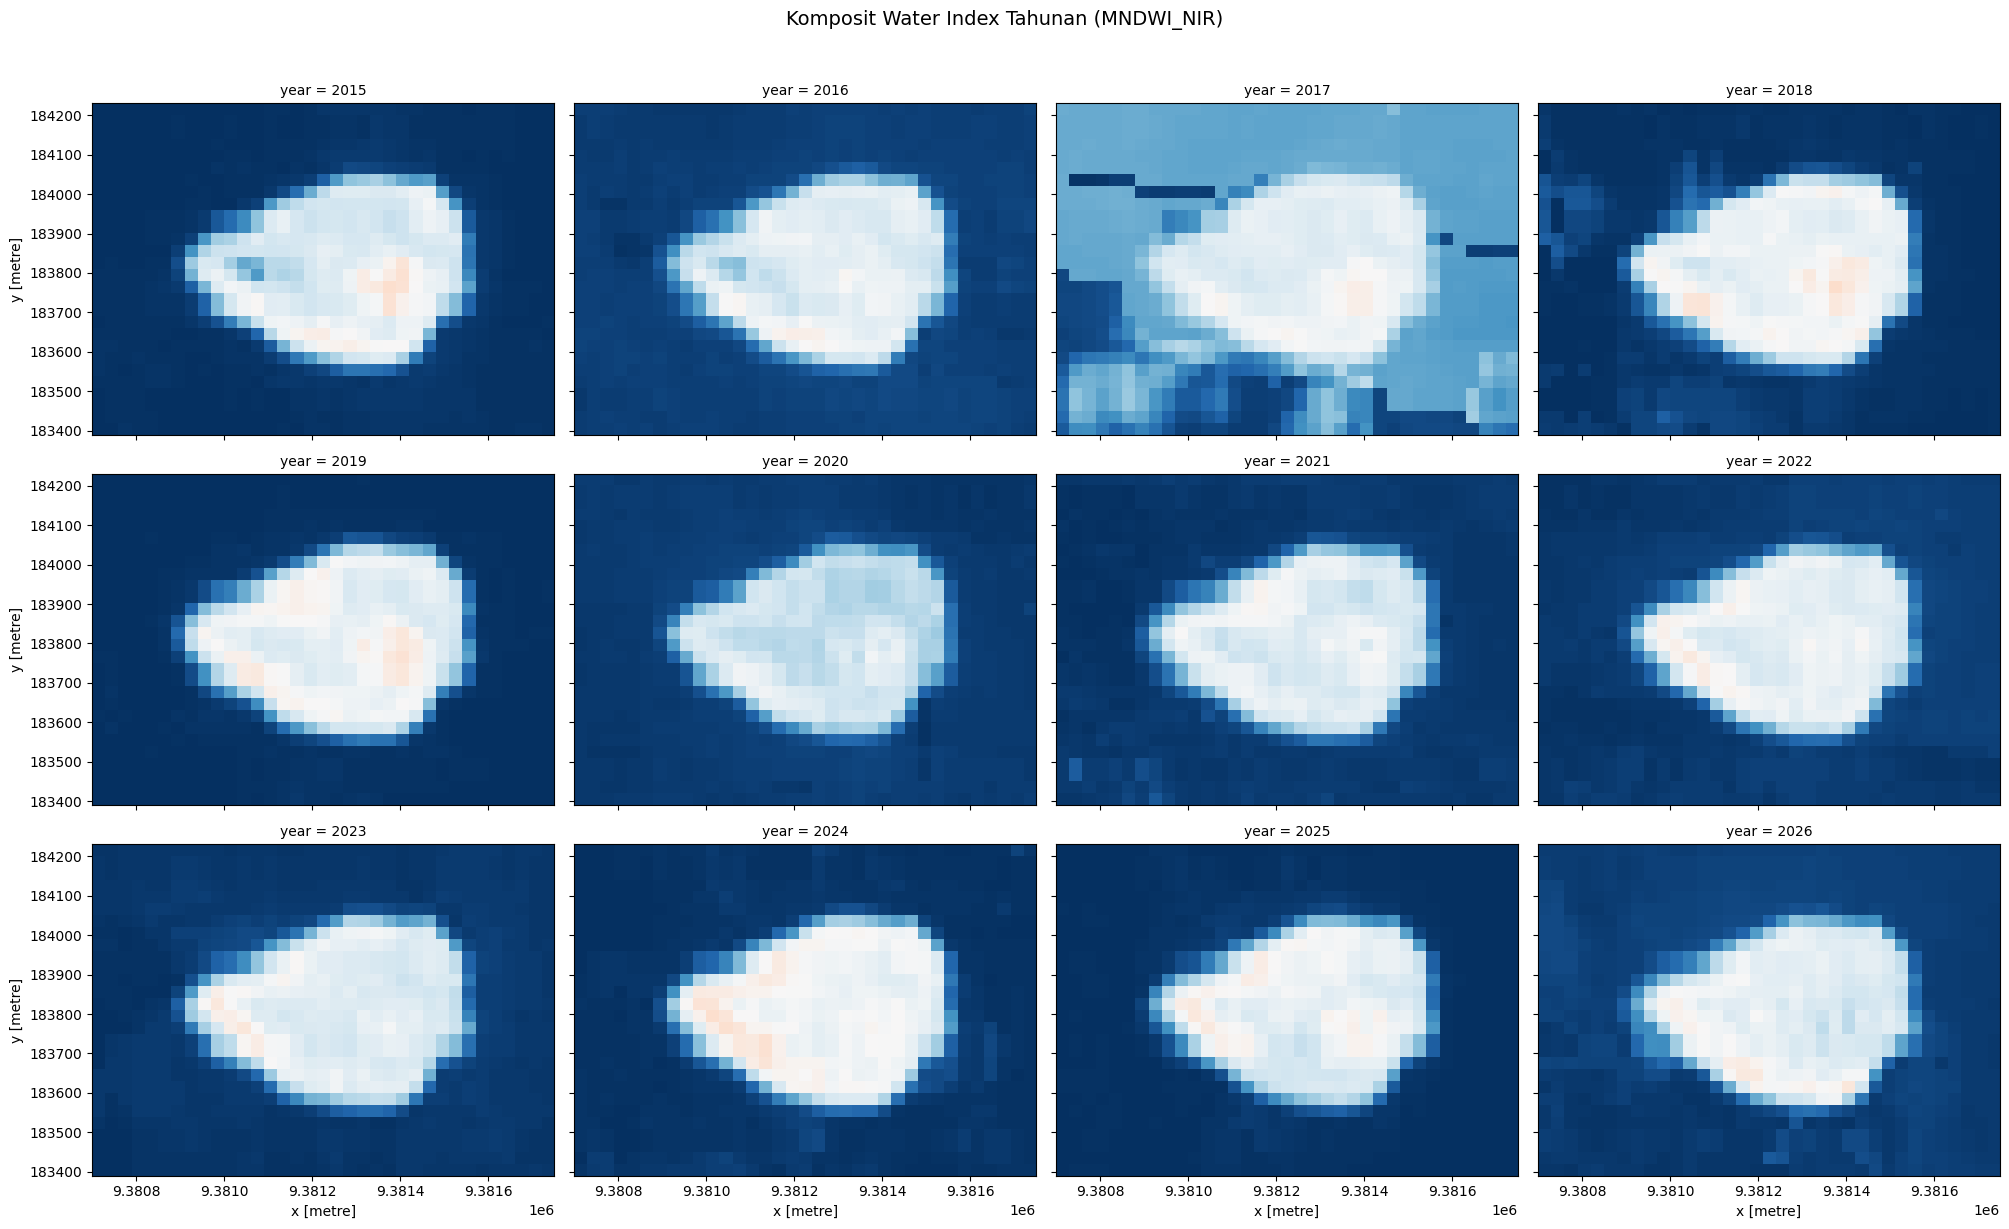

In [12]:
# Tentukan jumlah kolom berdasarkan jumlah tahun yang tersedia
n_years = len(grouped_by_year.year)
col_wrap = min(4, n_years)  # Maksimum 4 kolom per baris

grouped_by_year[wi].plot.imshow(
    col="year",
    col_wrap=col_wrap,
    size=4,
    cmap="RdBu",
    robust=True,
    aspect=1.2,
    add_colorbar=False
)

plt.suptitle(f"Komposit Water Index Tahunan ({wi.upper()})", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

## 9. Visualisasi Citra RGB Komposit Tahunan

Selain water index, kita juga membuat **komposit RGB tahunan** dari band merah, hijau, dan biru untuk memvisualisasikan kondisi aktual permukaan daratan dan perairan per tahun.

**Langkah pemrosesan:**
1. Reproject setiap band ke **EPSG:4326** (koordinat geografis) untuk visualisasi yang benar
2. Hitung **median tahunan** untuk menghilangkan noise dan awan sisa
3. **Normalisasi** ke rentang 0–1 menggunakan persentil 2–98% (menghindari outlier)
4. Plot grid multi-tahun

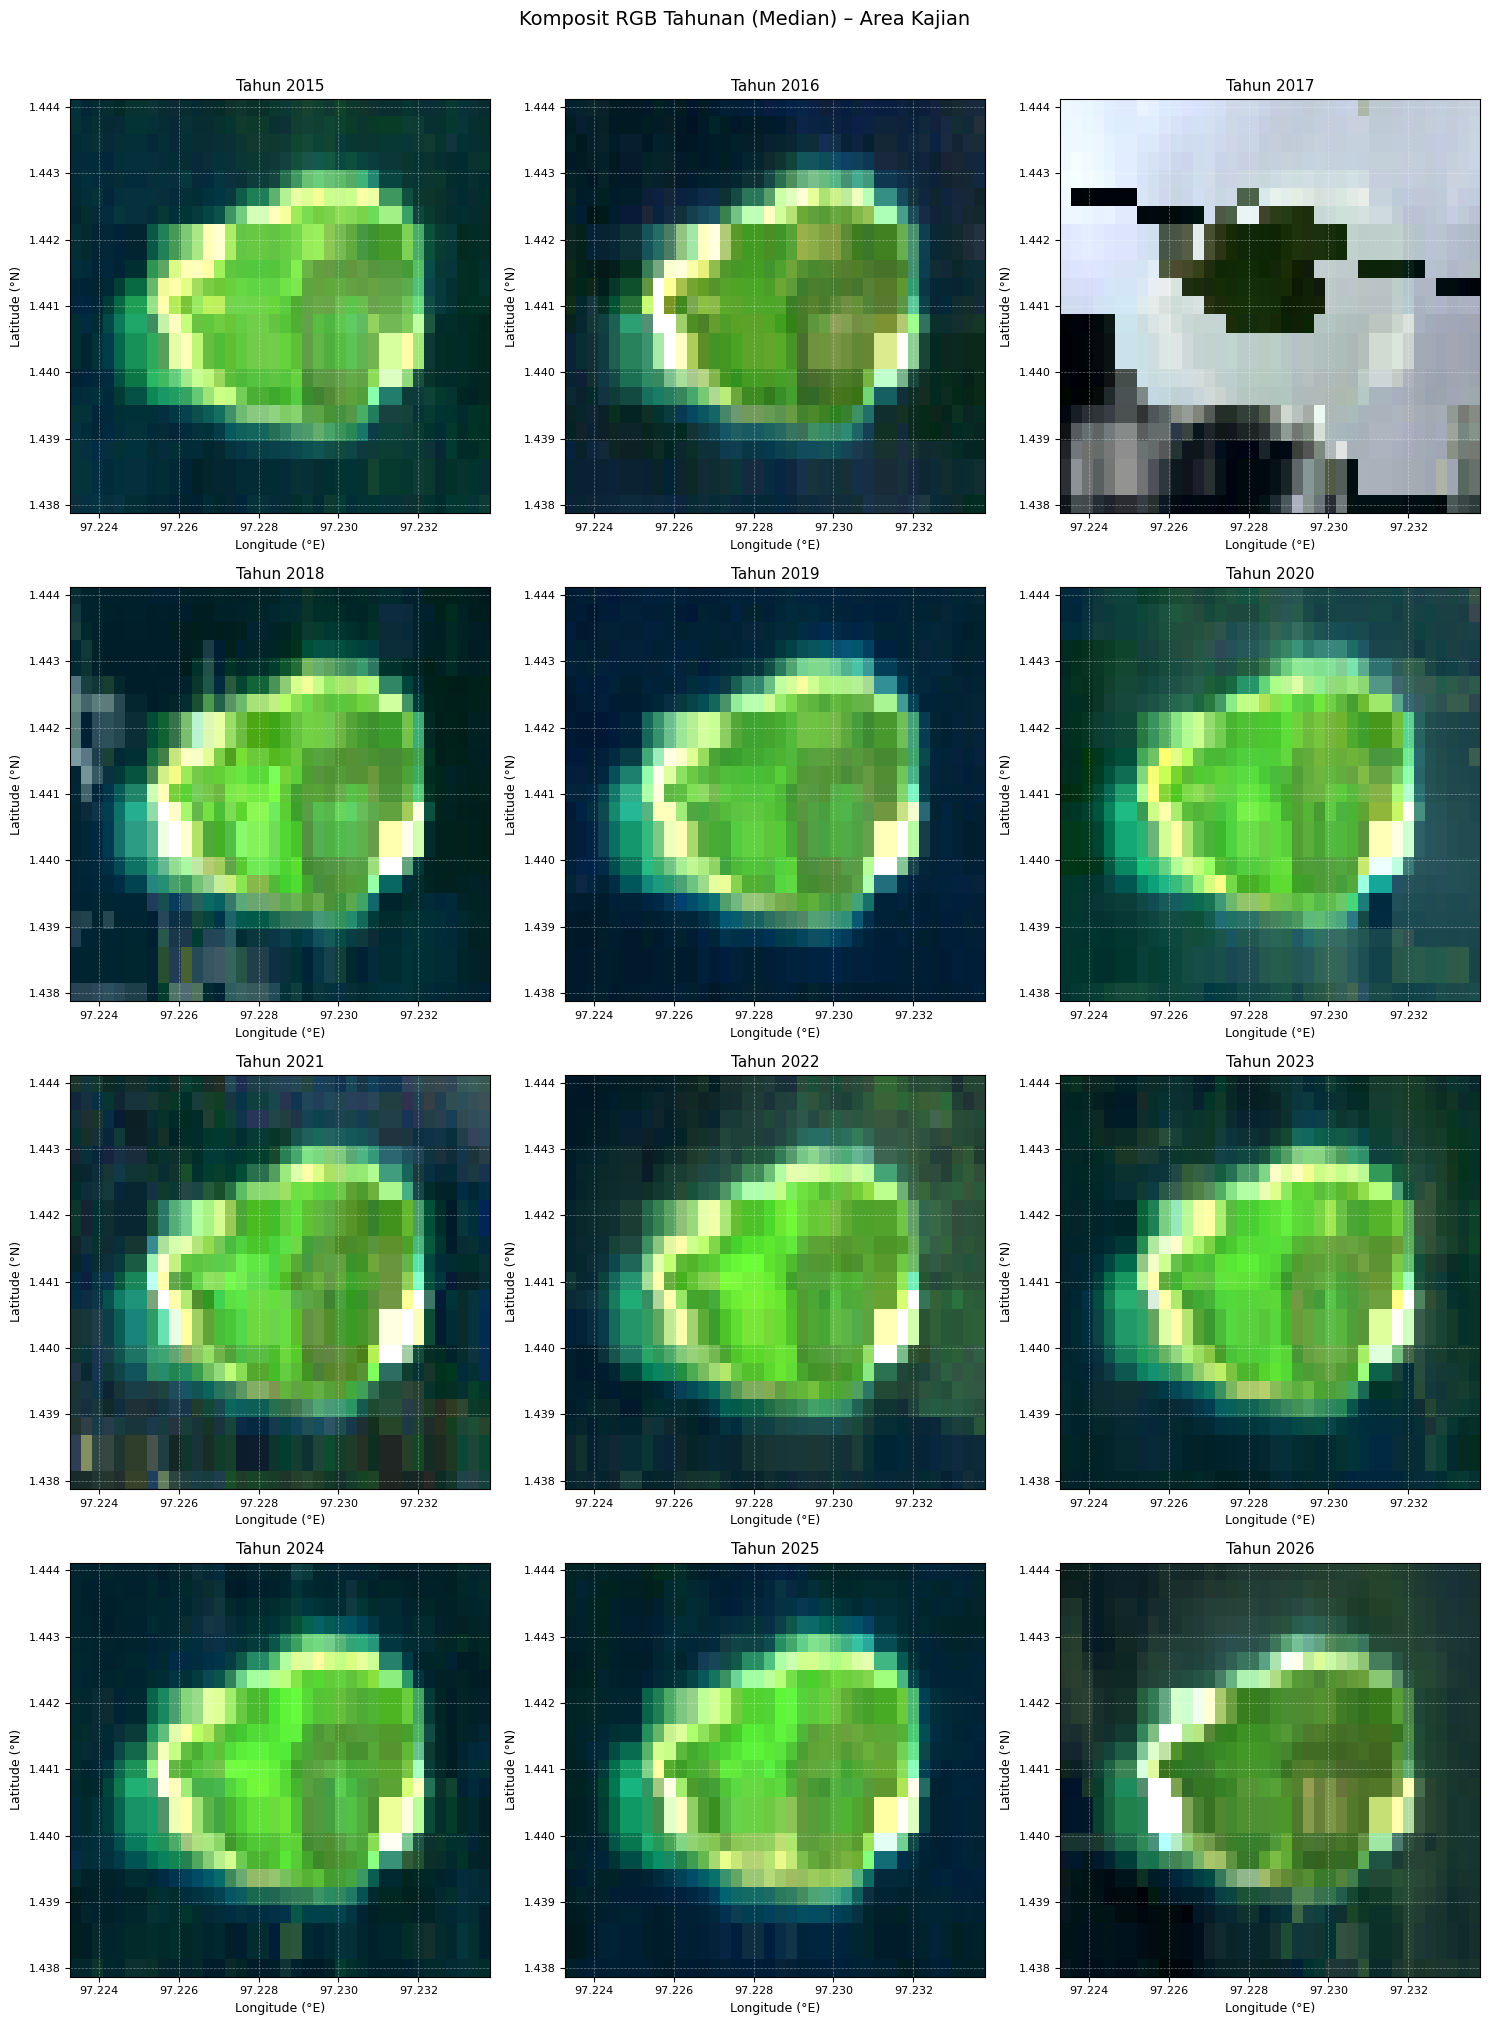

✅ Visualisasi RGB komposit selesai.


In [13]:
# Step 1: Reproject setiap band ke EPSG:4326 untuk visualisasi dengan koordinat geografis
red_geo   = data_tide_masked['red'].rio.reproject("EPSG:4326")
green_geo = data_tide_masked['green'].rio.reproject("EPSG:4326")
blue_geo  = data_tide_masked['blue'].rio.reproject("EPSG:4326")

# Step 2: Agregasi median per tahun
red_by_year   = red_geo.groupby("time.year").median()
green_by_year = green_geo.groupby("time.year").median()
blue_by_year  = blue_geo.groupby("time.year").median()

# Step 3: Dapatkan extent spasial untuk plotting
lons   = red_by_year.x.values
lats   = red_by_year.y.values
extent = [lons.min(), lons.max(), lats.min(), lats.max()]

# Step 4: Bangun array RGB ternormalisasi untuk setiap tahun
years      = red_by_year['year'].values
rgb_arrays = []

for year in years:
    r = red_by_year.sel(year=year).values
    g = green_by_year.sel(year=year).values
    b = blue_by_year.sel(year=year).values

    # Stack ke format (H, W, 3)
    rgb = np.stack([r, g, b], axis=-1)

    # Normalisasi stretch 2–98 persentil untuk kontras optimal
    p2  = np.nanpercentile(rgb, 2)
    p98 = np.nanpercentile(rgb, 98)
    rgb_norm = np.clip((rgb - p2) / (p98 - p2 + 1e-9), 0, 1)  # +1e-9 hindari pembagian nol
    rgb_arrays.append(rgb_norm)

# Step 5: Plot grid multi-tahun
col_wrap = 3
n_years  = len(years)
n_cols   = col_wrap
n_rows   = int(np.ceil(n_years / col_wrap))
size     = 5

fig, axes = plt.subplots(n_rows, n_cols, figsize=(size * n_cols, size * n_rows))
axes = axes.flatten() if n_years > 1 else [axes]

for i, (year, rgb_img) in enumerate(zip(years, rgb_arrays)):
    ax = axes[i]
    ax.imshow(rgb_img, extent=extent, origin='upper', aspect='auto')
    ax.grid(True, linestyle='--', alpha=0.4, color='white', linewidth=0.5)
    ax.set_xlabel('Longitude (°E)', fontsize=9)
    ax.set_ylabel('Latitude (°N)', fontsize=9)
    ax.set_title(f'Tahun {year}', fontsize=11)
    ax.tick_params(labelsize=8)

# Sembunyikan subplot yang tidak terpakai
for j in range(n_years, len(axes)):
    axes[j].axis('off')

plt.suptitle("Komposit RGB Tahunan (Median) – Area Kajian", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()
print("✅ Visualisasi RGB komposit selesai.")

⏳ Computing data_tide_masked...
✅ Selesai.
  ✅ Tahun 2015: 2622 piksel valid
  ✅ Tahun 2016: 2622 piksel valid
  ✅ Tahun 2017: 2622 piksel valid
  ✅ Tahun 2018: 2622 piksel valid
  ✅ Tahun 2019: 2622 piksel valid
  ✅ Tahun 2020: 2622 piksel valid
  ✅ Tahun 2021: 2622 piksel valid
  ✅ Tahun 2022: 2622 piksel valid
  ✅ Tahun 2023: 2622 piksel valid
  ✅ Tahun 2024: 2622 piksel valid
  ✅ Tahun 2025: 2622 piksel valid
  ✅ Tahun 2026: 2622 piksel valid


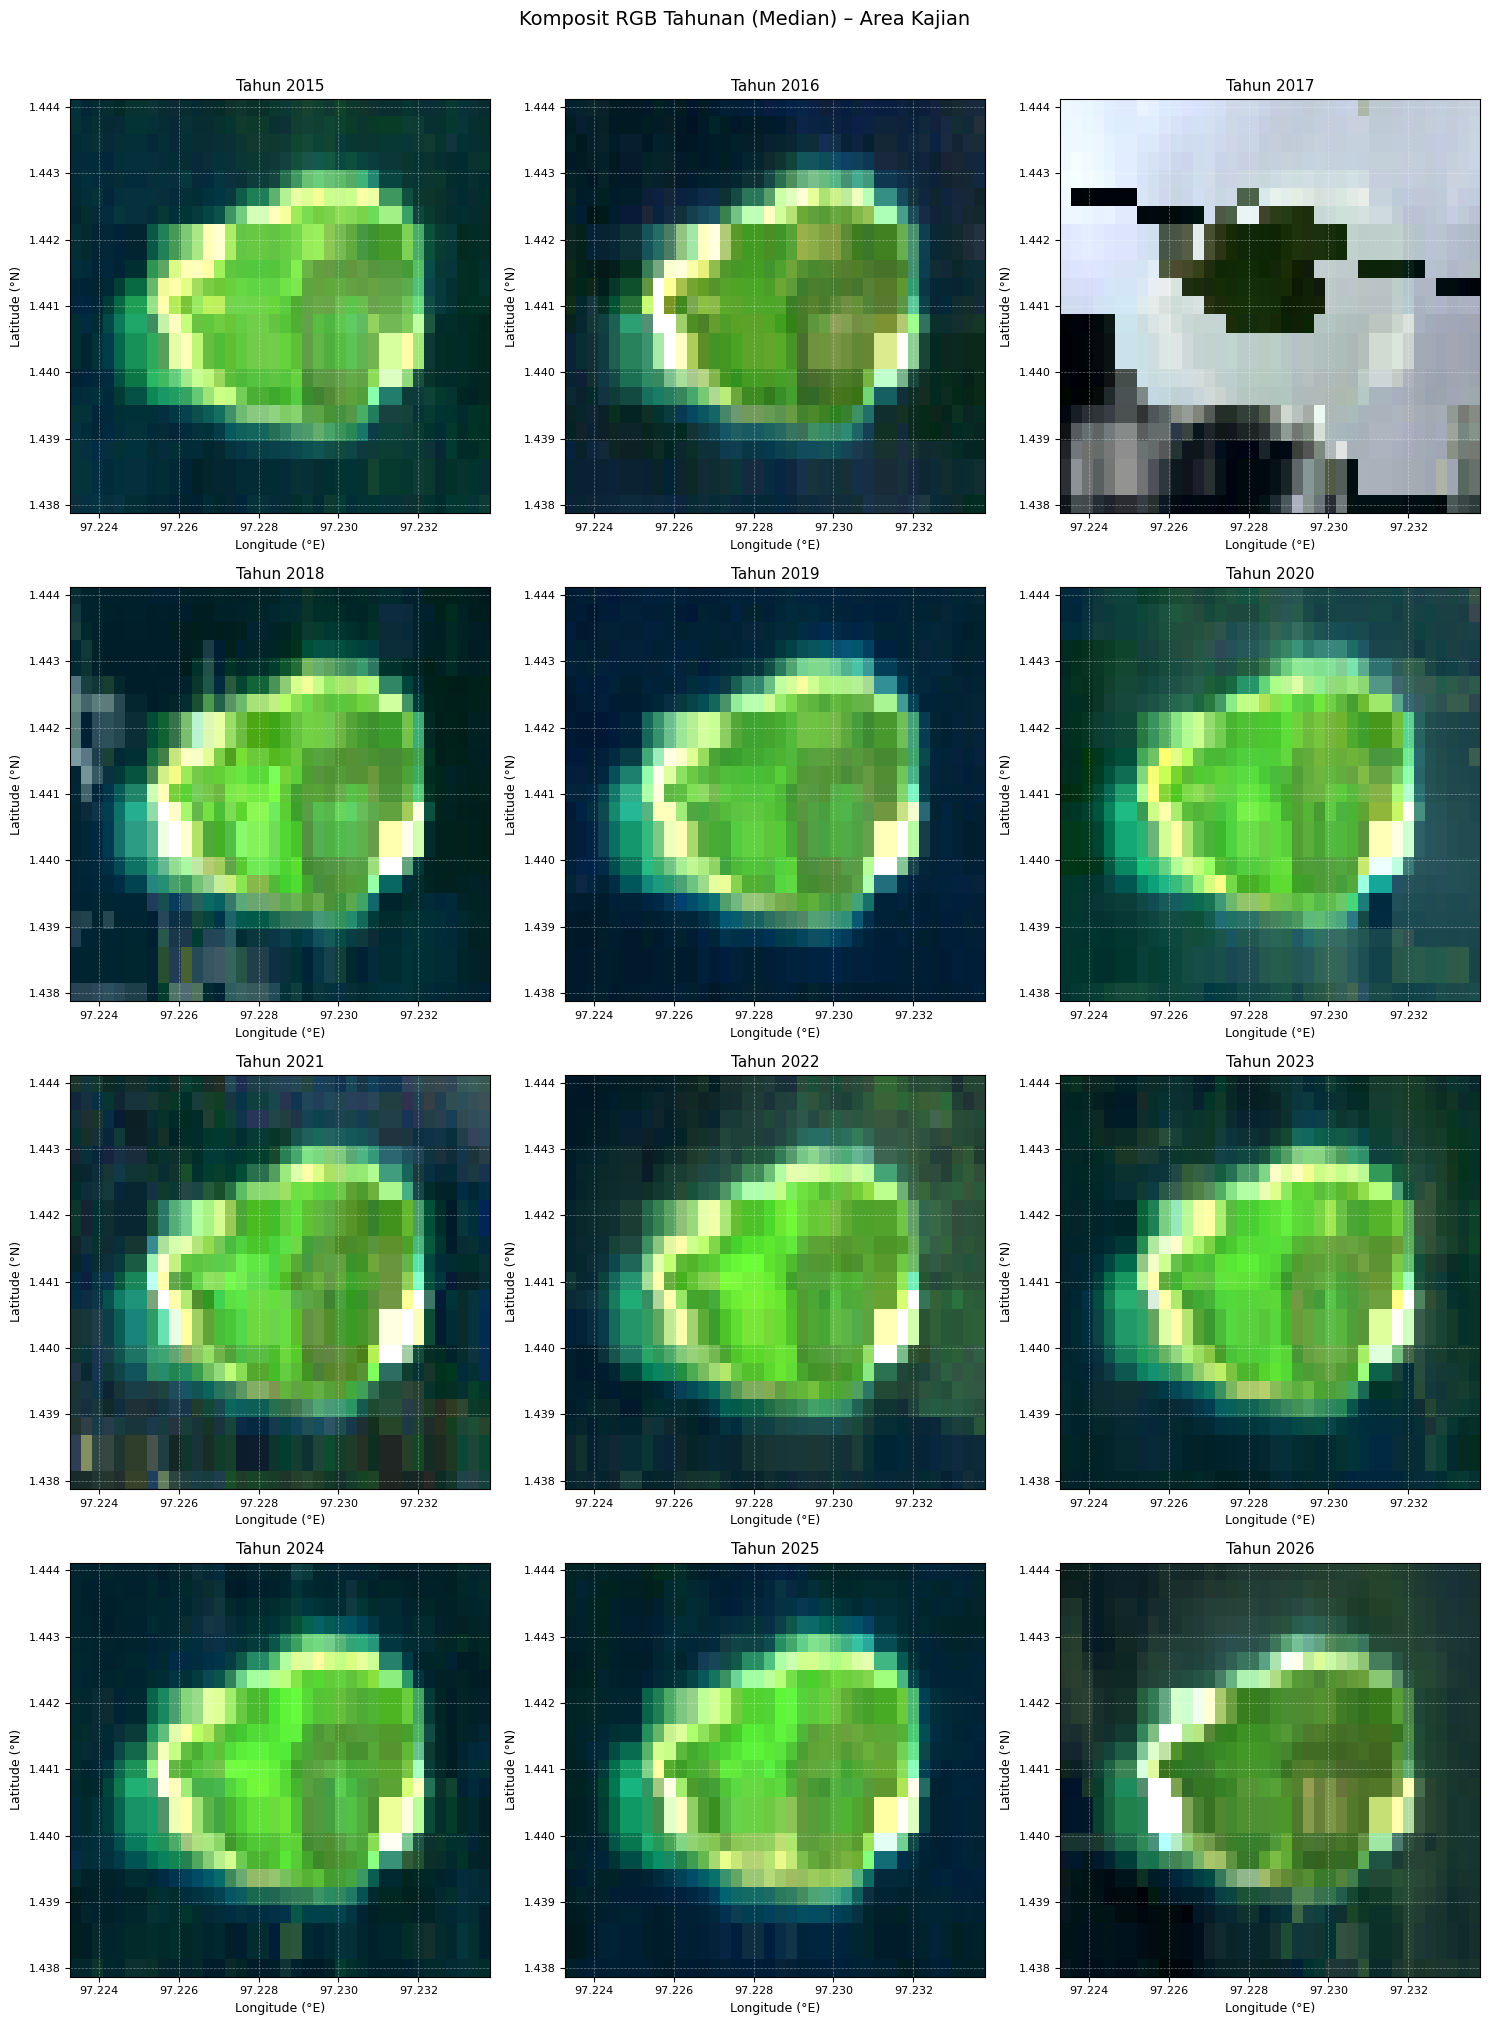

✅ Visualisasi RGB komposit selesai.


In [14]:
import rioxarray

# ── Pastikan data sudah di-compute dulu ──
print("⏳ Computing data_tide_masked...")
data_computed = data_tide_masked.compute()
print("✅ Selesai.")

# Step 1: Reproject dengan nodata eksplisit agar tidak konflik dengan nilai 0
# nodata=np.nan → nilai kosong diisi NaN, bukan 0
red_geo   = data_computed['red'].rio.write_nodata(np.nan).rio.reproject("EPSG:4326", nodata=np.nan)
green_geo = data_computed['green'].rio.write_nodata(np.nan).rio.reproject("EPSG:4326", nodata=np.nan)
blue_geo  = data_computed['blue'].rio.write_nodata(np.nan).rio.reproject("EPSG:4326", nodata=np.nan)

# Step 2: Agregasi median per tahun
red_by_year   = red_geo.groupby("time.year").median()
green_by_year = green_geo.groupby("time.year").median()
blue_by_year  = blue_geo.groupby("time.year").median()

# Step 3: Extent spasial
lons   = red_by_year.x.values
lats   = red_by_year.y.values
extent = [lons.min(), lons.max(), lats.min(), lats.max()]

# Step 4: Bangun array RGB ternormalisasi
years      = red_by_year['year'].values
rgb_arrays = []

for year in years:
    r = red_by_year.sel(year=year).values
    g = green_by_year.sel(year=year).values
    b = blue_by_year.sel(year=year).values

    rgb = np.stack([r, g, b], axis=-1)

    # Cek apakah array tidak kosong
    valid_pixels = np.sum(~np.isnan(rgb))
    if valid_pixels == 0:
        print(f"  ⚠️  Tahun {year}: tidak ada piksel valid, dilewati")
        rgb_arrays.append(np.zeros_like(rgb))
        continue

    p2  = np.nanpercentile(rgb, 2)
    p98 = np.nanpercentile(rgb, 98)
    rgb_norm = np.clip((rgb - p2) / (p98 - p2 + 1e-9), 0, 1)

    # Ganti NaN dengan 0 untuk plotting (tampil hitam)
    rgb_norm = np.nan_to_num(rgb_norm, nan=0.0)
    rgb_arrays.append(rgb_norm)
    print(f"  ✅ Tahun {year}: {valid_pixels} piksel valid")

# Step 5: Plot
col_wrap = 3
n_years  = len(years)
n_cols   = col_wrap
n_rows   = int(np.ceil(n_years / col_wrap))
size     = 5

fig, axes = plt.subplots(n_rows, n_cols, figsize=(size * n_cols, size * n_rows))
axes = axes.flatten() if n_years > 1 else [axes]

for i, (year, rgb_img) in enumerate(zip(years, rgb_arrays)):
    ax = axes[i]
    ax.imshow(rgb_img, extent=extent, origin='upper', aspect='auto')
    ax.grid(True, linestyle='--', alpha=0.4, color='white', linewidth=0.5)
    ax.set_xlabel('Longitude (°E)', fontsize=9)
    ax.set_ylabel('Latitude (°N)', fontsize=9)
    ax.set_title(f'Tahun {year}', fontsize=11)
    ax.tick_params(labelsize=8)

for j in range(n_years, len(axes)):
    axes[j].axis('off')

plt.suptitle("Komposit RGB Tahunan (Median) – Area Kajian", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("rgb_komposit_tahunan.png", dpi=150, bbox_inches='tight')  # simpan juga ke file
plt.show()
print("✅ Visualisasi RGB komposit selesai.")

## 10. Ekstraksi Kontur Garis Pantai

Tahap kritis: mengekstraksi **kontur garis pantai** dari data water index menggunakan metode iso-contour. Kontur diekstrak pada nilai ambang (threshold) tertentu yang merepresentasikan batas antara air dan daratan.

| Water Index | Threshold (`z_value`) | Interpretasi |
|-------------|----------------------|-------------|
| `combined`  | `0.0` | Batas air/darat simetris |
| `mndwi_nir` | `0.65` | NDWI tinggi untuk dominasi air |
| `scowi` | `0.0` | Alternatif |

Hasil berupa **GeoDataFrame** berindeks `year`, berisi polyline garis pantai per tahun dalam sistem koordinat proyeksi.

In [15]:
from coastlines.utils import subpixel_contours

def extract_contours_fixed(
    dataset,
    z_values: float = 0.0,
    min_vertices: int = 15,
    index_name: str = "combined",
):
    """
    Versi perbaikan dari extract_contours() — fix bug index mismatch
    saat pd.concat menggabungkan GeoDataFrame dengan jumlah baris berbeda.
    """
    contour_dict = {}
    
    for year, da in dataset.groupby("year"):
        contours = subpixel_contours(
            da=da[index_name].squeeze(),
            z_values=z_values,
            crs=dataset.geobox.crs,
            min_vertices=min_vertices,
            verbose=False,
        )
        # Simpan geometri langsung per tahun (bukan concat belakangan)
        if contours is not None and len(contours) > 0:
            # Gabungkan semua geometri dalam satu tahun menjadi satu MultiLineString
            from shapely.ops import unary_union
            merged_geom = unary_union(contours.geometry.values)
            contour_dict[year] = merged_geom
        else:
            contour_dict[year] = None
    
    # Bangun GeoDataFrame dengan cara yang aman — index sudah pasti cocok
    contour_gdf = gpd.GeoDataFrame(
        {"geometry": list(contour_dict.values())},
        index=pd.Index(list(contour_dict.keys()), name="year"),
        crs=dataset.geobox.crs,
    )
    
    return contour_gdf

In [16]:
# Threshold sesuai water index yang dipilih
z_values = 0.65

# Gunakan fungsi yang sudah diperbaiki (fix bug index mismatch)
contour_gdf = extract_contours_fixed(
    grouped_by_year,
    z_values=z_values,
    index_name=wi
)

print(f"✅ Kontur garis pantai berhasil diekstrak.")
print(f"   Rentang tahun: {contour_gdf.index.min()} – {contour_gdf.index.max()}")
print(f"   Kontur valid : {contour_gdf.geometry.notna().sum()} tahun")

# Tampilkan peta — filter hanya yang valid
contour_gdf.dropna().reset_index().explore(
    column="year",
    cmap="magma",
    style_kwds={"weight": 3},
    tiles=basemaps.Esri.WorldImagery,
    tooltip="year",
)

✅ Kontur garis pantai berhasil diekstrak.
   Rentang tahun: 2015 – 2026
   Kontur valid : 12 tahun


In [17]:
# Filter hanya tahun yang punya kontur valid sebelum visualisasi
contour_valid = contour_gdf.dropna(subset=["geometry"])

print(f"Tahun tanpa kontur (dilewati): {contour_gdf[contour_gdf.geometry.isna()].index.tolist()}")
print(f"Tahun yang divisualisasikan  : {contour_valid.index.tolist()}")

Tahun tanpa kontur (dilewati): []
Tahun yang divisualisasikan  : [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]


## 11. Analisis Perubahan Garis Pantai

Dari kontur garis pantai yang telah diekstraksi, kita melakukan analisis perubahan spasial dan temporal:

### 11.1 Ekstraksi Titik Pengukuran
Titik-titik pengukuran ditempatkan setiap **30 meter** sepanjang garis pantai tahun referensi. Setiap titik mewakili satu lokasi pengukuran perubahan.

### 11.2 Pengukuran Pergerakan Tahunan
Untuk setiap titik, dihitung jarak perpindahan garis pantai ke titik terdekat pada kontur tahun-tahun lain — menghasilkan **time series perubahan** per titik.

### 11.3 Analisis Regresi Linear
Regresi linear diterapkan pada time series perubahan tiap titik, menghasilkan:
- **`rate_time`**: laju perubahan (meter/tahun), negatif = erosi, positif = akresi
- **`se_time`**: standar error regresi
- **`sig_time`**: nilai p-value (signifikansi statistik)

> **⚠️ Catatan:** Tahun baseline (`baseline_year`) harus disesuaikan dengan tahun terakhir yang tersedia di `contour_gdf`. Nilai 2023 digunakan jika data mencakup tahun tersebut.

In [18]:
# Gunakan contour_gdf_valid (sudah difilter, tanpa geometri None)
baseline_year = int(contour_valid.index.max())
print(f"📌 Tahun baseline analisis: {baseline_year}")
print(f"   Tahun yang dianalisis: {contour_valid.index.tolist()}")

# Step 1: Tempatkan titik pengukuran setiap 30m di sepanjang garis pantai baseline
points_gdf = points_on_line(contour_valid, index=baseline_year, distance=30)
print(f"   Jumlah titik pengukuran: {len(points_gdf)}")

# Step 2: Hitung perpindahan tahunan untuk setiap titik
points_gdf = annual_movements(
    points_gdf,
    contours_gdf=contour_valid,   # ← ganti dari contour_gdf
    yearly_ds=grouped_by_year,
    baseline_year=baseline_year,
    water_index=wi,
)

# Step 3: Hitung regresi linear untuk mendapatkan laju perubahan
points_gdf = calculate_regressions(points_gdf=points_gdf)

print(f"✅ Analisis perubahan selesai.")
print(f"   Rata-rata laju perubahan: {points_gdf['rate_time'].mean():.2f} m/tahun")
print(f"   Titik dengan tren signifikan (p<0.05): {(points_gdf['sig_time'] <= 0.05).sum()} dari {len(points_gdf)}")

📌 Tahun baseline analisis: 2026
   Tahun yang dianalisis: [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]
   Jumlah titik pengukuran: 62
✅ Analisis perubahan selesai.
   Rata-rata laju perubahan: -0.35 m/tahun
   Titik dengan tren signifikan (p<0.05): 5 dari 62


## 12. Visualisasi Akhir: Peta Perubahan Garis Pantai

Visualisasi final menggabungkan dua layer informasi:

1. **Kontur garis pantai** per tahun (layer polyline, warna gradien waktu menggunakan colormap `inferno`)
2. **Titik perubahan** dengan warna menunjukkan laju perubahan:
   - 🔵 **Biru** → akresi (garis pantai maju/bertambah)
   - 🔴 **Merah** → erosi (garis pantai mundur/berkurang)
   - Label interaktif menampilkan detail laju perubahan saat diklik

Titik dengan tren yang **tidak signifikan secara statistik** (p > 0.05) diberi label khusus.

In [19]:
# Buat label HTML interaktif untuk setiap titik
points_gdf["Perubahan Pantai"] = points_gdf.apply(
    lambda x: (
        f"<h4>Garis pantai {'<b>mundur (erosi)</b>' if x.rate_time < 0 else '<b>maju (akresi)</b>'} "
        f"sebesar<br><b>{abs(x.rate_time):.2f} m (±{x.se_time:.1f}) per tahun</b><br>"
        f"sejak tahun <b>{contour_gdf.index[0]}</b></h4>"
    ),
    axis=1,
)

# Ganti label untuk titik yang tidak memiliki tren signifikan
points_gdf.loc[
    points_gdf.sig_time > 0.05, "Perubahan Pantai"
] = "<h4>Tidak ada tren signifikan (p > 0.05)</h4>"

# Layer 1: Kontur garis pantai per tahun
m = contour_gdf.reset_index().explore(
    column="year",
    cmap="inferno",
    tooltip="year",
    popup="year",
    style_kwds={"opacity": 0.6, "weight": 2},
    categorical=True,
    tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}",
    attr="ESRI WorldImagery",
    legend=True,
    legend_kwds={"caption": "Tahun"},
)

# Layer 2: Titik perubahan dengan warna laju perubahan
points_gdf.explore(
    m=m,
    column="rate_time",
    cmap="RdBu",
    markersize=5,
    tooltip="Perubahan Pantai",
    popup="Perubahan Pantai",
    legend=True,
    legend_kwds={"caption": "Laju Perubahan (m/tahun)"},
)

### 12.1 Statistik Distribusi Laju Perubahan

Histogram distribusi laju perubahan di seluruh titik pengukuran untuk memahami karakteristik perubahan di area kajian secara keseluruhan.

In [20]:
# Cek distribusi nilai rate_time
print("Statistik rate_time:")
print(points_gdf['rate_time'].describe())
print()

# Cek apakah ada NaN
print(f"Jumlah NaN di rate_time: {points_gdf['rate_time'].isna().sum()}")
print()

# Cek nilai ekstrem
print(f"Nilai maksimum (akresi terbesar) : {points_gdf['rate_time'].max():.2f} m/tahun")
print(f"Nilai minimum (erosi terbesar)   : {points_gdf['rate_time'].min():.2f} m/tahun")
print()

# Cek berapa titik yang terklasifikasi
print(f"Titik erosi   (rate < 0) : {(points_gdf['rate_time'] < 0).sum()}")
print(f"Titik akresi  (rate > 0) : {(points_gdf['rate_time'] > 0).sum()}")
print(f"Titik sig     (p < 0.05) : {(points_gdf['sig_time'] <= 0.05).sum()}")
print(f"Titik tidak sig (p>0.05) : {(points_gdf['sig_time'] > 0.05).sum()}")
print()

# Cek apakah label sudah terbuat dengan benar
print("Contoh label 5 titik akresi terbesar:")
print(points_gdf.nlargest(5, 'rate_time')[['rate_time', 'se_time', 'sig_time', 'Perubahan Pantai']])

Statistik rate_time:
count    62.000000
mean     -0.353226
std       0.300223
min      -1.710000
25%      -0.484500
50%      -0.314500
75%      -0.179250
max       0.100000
Name: rate_time, dtype: float64

Jumlah NaN di rate_time: 0

Nilai maksimum (akresi terbesar) : 0.10 m/tahun
Nilai minimum (erosi terbesar)   : -1.71 m/tahun

Titik erosi   (rate < 0) : 58
Titik akresi  (rate > 0) : 4
Titik sig     (p < 0.05) : 5
Titik tidak sig (p>0.05) : 57

Contoh label 5 titik akresi terbesar:
    rate_time  se_time  sig_time  \
8       0.100    0.362     0.789   
7       0.086    0.284     0.769   
6       0.049    0.325     0.884   
15      0.039    0.169     0.824   
9      -0.020    0.294     0.947   

                                 Perubahan Pantai  
8   <h4>Tidak ada tren signifikan (p > 0.05)</h4>  
7   <h4>Tidak ada tren signifikan (p > 0.05)</h4>  
6   <h4>Tidak ada tren signifikan (p > 0.05)</h4>  
15  <h4>Tidak ada tren signifikan (p > 0.05)</h4>  
9   <h4>Tidak ada tren signifikan 

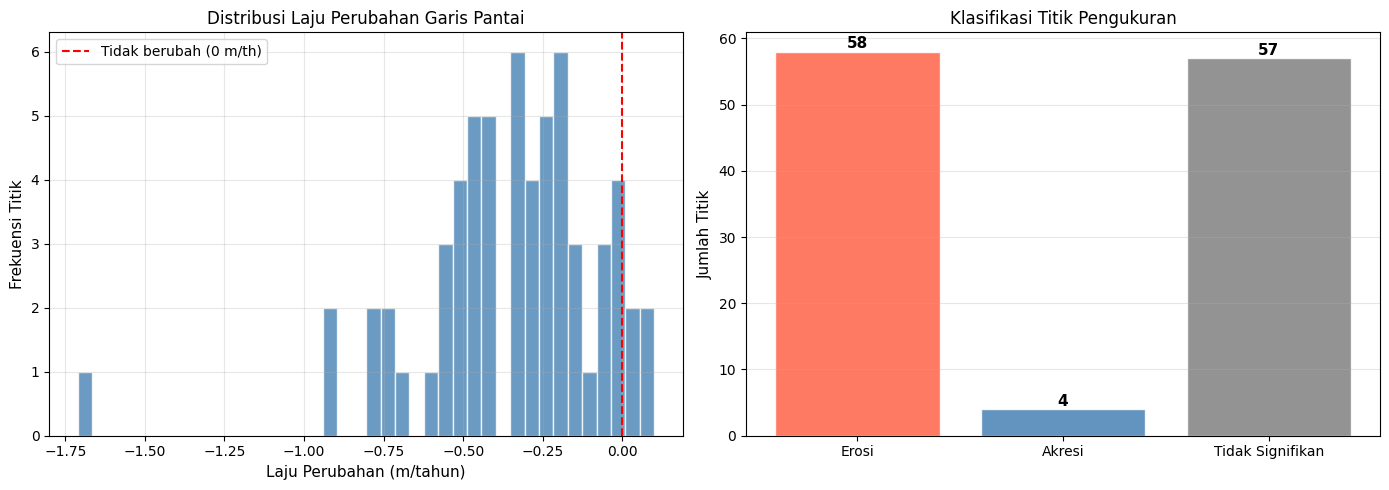


📊 Ringkasan Hasil:
   Total titik pengukuran : 62
   Titik erosi            : 58 (93.5%)
   Titik akresi           : 4 (6.5%)
   Tidak signifikan       : 57 (91.9%)
   Rata-rata laju         : -0.35 ± 0.30 m/tahun


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Histogram laju perubahan
ax = axes[0]
points_gdf['rate_time'].hist(bins=40, ax=ax, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(0, color='red', linestyle='--', linewidth=1.5, label='Tidak berubah (0 m/th)')
ax.set_title('Distribusi Laju Perubahan Garis Pantai', fontsize=12)
ax.set_xlabel('Laju Perubahan (m/tahun)', fontsize=11)
ax.set_ylabel('Frekuensi Titik', fontsize=11)
ax.legend()
ax.grid(alpha=0.3)

# Plot 2: Statistik ringkasan
ax2 = axes[1]
erosion  = (points_gdf['rate_time'] < 0).sum()
accretion = (points_gdf['rate_time'] > 0).sum()
stable   = (points_gdf['sig_time'] > 0.05).sum()

ax2.bar(['Erosi', 'Akresi', 'Tidak Signifikan'], [erosion, accretion, stable],
        color=['tomato', 'steelblue', 'gray'], edgecolor='white', alpha=0.85)
ax2.set_title('Klasifikasi Titik Pengukuran', fontsize=12)
ax2.set_ylabel('Jumlah Titik', fontsize=11)
ax2.grid(axis='y', alpha=0.3)
for i, v in enumerate([erosion, accretion, stable]):
    ax2.text(i, v + 0.5, str(v), ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n📊 Ringkasan Hasil:")
print(f"   Total titik pengukuran : {len(points_gdf)}")
print(f"   Titik erosi            : {erosion} ({100*erosion/len(points_gdf):.1f}%)")
print(f"   Titik akresi           : {accretion} ({100*accretion/len(points_gdf):.1f}%)")
print(f"   Tidak signifikan       : {stable} ({100*stable/len(points_gdf):.1f}%)")
print(f"   Rata-rata laju         : {points_gdf['rate_time'].mean():.2f} ± {points_gdf['rate_time'].std():.2f} m/tahun")

## 13. Ekspor Hasil ke GeoPackage

Hasil analisis diekspor ke format **GeoPackage (.gpkg)** yang merupakan format geospasial open-source berbasis SQLite. GeoPackage dipilih karena:
- Satu file berisi banyak layer
- Kompatibel dengan QGIS, ArcGIS, PostGIS, dan tools geospasial lainnya
- Mendukung proyeksi dan metadata yang lengkap

Dua file diekspor:
1. **`{lokasi}_rate_of_change.gpkg`** — titik perubahan dengan laju per tahun
2. **`{lokasi}_shorelines.gpkg`** — kontur garis pantai per tahun

In [24]:
# Nama lokasi untuk penamaan file output
location = "Nias Utara"  # Ubah sesuai nama lokasi Anda

# Ekspor titik laju perubahan garis pantai
output_points = f"{location}_rate_of_change.gpkg"
points_gdf.to_file(output_points, layer="rate_of_change", driver="GPKG")
print(f"✅ Ekspor titik perubahan: {output_points}")

# Ekspor kontur garis pantai tahunan
output_contours = f"{location}_shorelines.gpkg"
contour_gdf.to_file(output_contours, layer="shorelines", driver="GPKG")
print(f"✅ Ekspor kontur garis pantai: {output_contours}")

print(f"\n🎉 Analisis selesai! File tersimpan di direktori kerja saat ini.")

✅ Ekspor titik perubahan: Nias Utara_rate_of_change.gpkg
✅ Ekspor kontur garis pantai: Nias Utara_shorelines.gpkg

🎉 Analisis selesai! File tersimpan di direktori kerja saat ini.
